In [26]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs
from skactiveml.pool import UncertaintySampling
from skactiveml.utils import MISSING_LABEL
from skactiveml.classifier import SklearnClassifier

In [27]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the IRIS dataset.
iris = load_iris()
X_iris, y_true_iris = iris.data, iris.target

In [28]:
def prepare_dataset(X, y):
    # Split the data into training (85%) and testing (15%) sets
    X, X_test, y_true, y_true_test = train_test_split(X, y, test_size=0.15, random_state=42)

    # Create an array with missing labels
    y = np.full(shape=y_true.shape, fill_value=MISSING_LABEL)

    # Use the first 10 samples as initial training data.
    y[:10] = y_true[:10]

    return X, y, y_true, X_test, y_true_test

X, y, y_true, X_test, y_true_test = prepare_dataset(X_iris, y_true_iris)

In [29]:
def train_model(classifier, X, y, y_true, sampler, X_test, y_true_test, history=None, n_rounds=20):
    # Initialize history if None
    if history is None:
        history = []
    
    for i in range(n_rounds):
        # select sample based on sampler
        query_idx = sampler.query(X, y, clf=classifier)

        # simulate oracle
        y[query_idx] = y_true[query_idx]

        # train on new sample
        classifier.fit(X, y)
        
        
        # Record performance
        y_pred = classifier.predict(X_test)
        
        # Calculate accuracy
        accuracy = np.mean(y_pred == y_true_test)
        
        # Calculate cross-entropy loss
        y_proba = classifier.predict_proba(X_test)
        
        # One-hot encode true labels
        n_classes = len(np.unique(y_true_test))
        y_true_one_hot = np.zeros((len(y_true_test), n_classes))
        for j, label in enumerate(y_true_test):
            y_true_one_hot[j, label] = 1
        
        # Calculate cross-entropy loss
        eps = 1e-15
        y_proba = np.clip(y_proba, eps, 1 - eps)
        loss = -np.sum(y_true_one_hot * np.log(y_proba)) / len(y_true_test)
        
        # Add metrics to history
        history.append((loss, accuracy))

    return classifier, history

In [30]:
def end_to_end_bench(expriment_title, classifier, X, y_true, y, X_test, y_true_test, sampler, n_rounds=20):
    # Train
    classifer, history = train_model(classifier, X, y, y_true, sampler, X_test, y_true_test, n_rounds=n_rounds)

    # Vsualize results
    import matplotlib.pyplot as plt
    # Extract loss and accuracy from history
    losses, accuracies = zip(*history)
    # Create subplots for loss and accuracy
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    ax1.plot(losses)
    ax1.set_title(f'Cross-Entropy Loss | {expriment_title}')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')

    # Plot accuracy
    ax2.plot(accuracies)
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

    return classifier, history

In [31]:
# Create classifier and query strategy.
sampler_least_confidence = UncertaintySampling(method='least_confident')
sampler_entropy = UncertaintySampling(method='entropy')
sampler_margin = UncertaintySampling(method='margin_sampling')

In [ ]:
def generate_classifier(y_true):
    # Create a Logistic Regression classifier
    return SklearnClassifier(LogisticRegression(), classes=np.unique(y_true))

N_ROUNDS = 10

def main(x_ground, y_ground):
    # Run end-to-end benchmark for different samplers
    X, y, y_true, X_test, y_true_test = prepare_dataset(x_ground, y_ground)
    _, history = end_to_end_bench("Least Confidence Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_least_confidence, n_rounds=N_ROUNDS)

    X, y, y_true, X_test, y_true_test = prepare_dataset(X_iris, y_true_iris)
    _, history = end_to_end_bench("Entropy Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_entropy, n_rounds=N_ROUNDS)

    X, y, y_true, X_test, y_true_test = prepare_dataset(X_iris, y_true_iris)
    _, history = end_to_end_bench("Margin Sampling", generate_classifier(y_true), X, y_true, y, X_test, y_true_test, sampler_margin, n_rounds=N_ROUNDS)


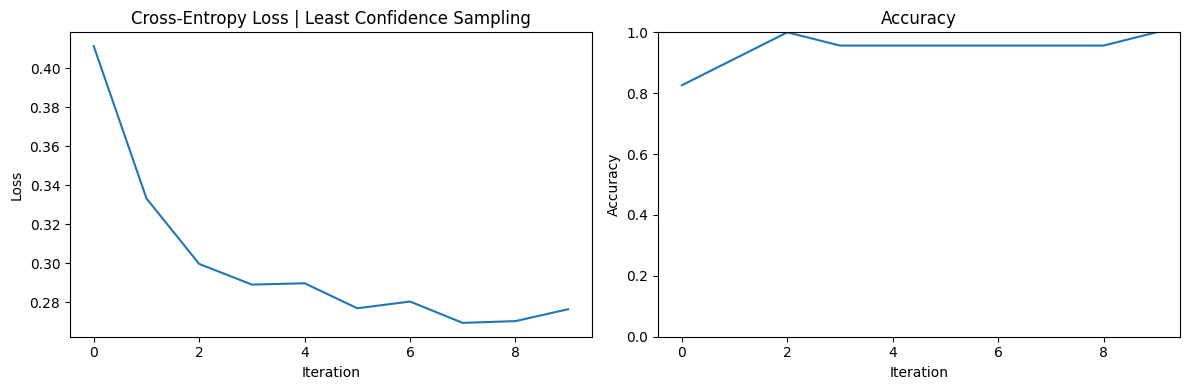

[(np.float64(0.41144968139309684), np.float64(0.8260869565217391)), (np.float64(0.3332665148334658), np.float64(0.9130434782608695)), (np.float64(0.299632680880244), np.float64(1.0)), (np.float64(0.2890067692920108), np.float64(0.9565217391304348)), (np.float64(0.2896913560703574), np.float64(0.9565217391304348)), (np.float64(0.2768511703849969), np.float64(0.9565217391304348)), (np.float64(0.28030325679889934), np.float64(0.9565217391304348)), (np.float64(0.26934311068720923), np.float64(0.9565217391304348)), (np.float64(0.27025847527344854), np.float64(0.9565217391304348)), (np.float64(0.2763560285161857), np.float64(1.0))]


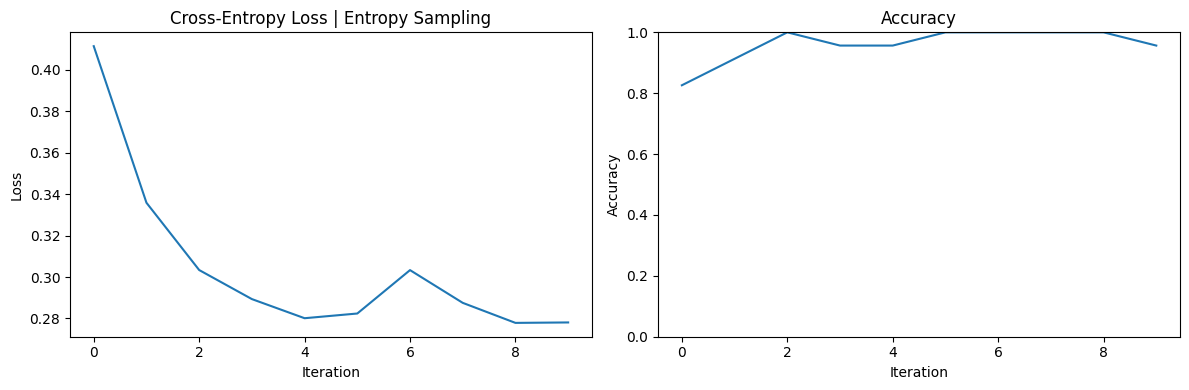

[(np.float64(0.41144968139309684), np.float64(0.8260869565217391)), (np.float64(0.3358582415032142), np.float64(0.9130434782608695)), (np.float64(0.3033736717838763), np.float64(1.0)), (np.float64(0.28934644092872547), np.float64(0.9565217391304348)), (np.float64(0.28011154704613483), np.float64(0.9565217391304348)), (np.float64(0.2823847767695105), np.float64(1.0)), (np.float64(0.3033351748593015), np.float64(1.0)), (np.float64(0.28753025644279484), np.float64(1.0)), (np.float64(0.277857769992152), np.float64(1.0)), (np.float64(0.27806889670261464), np.float64(0.9565217391304348))]


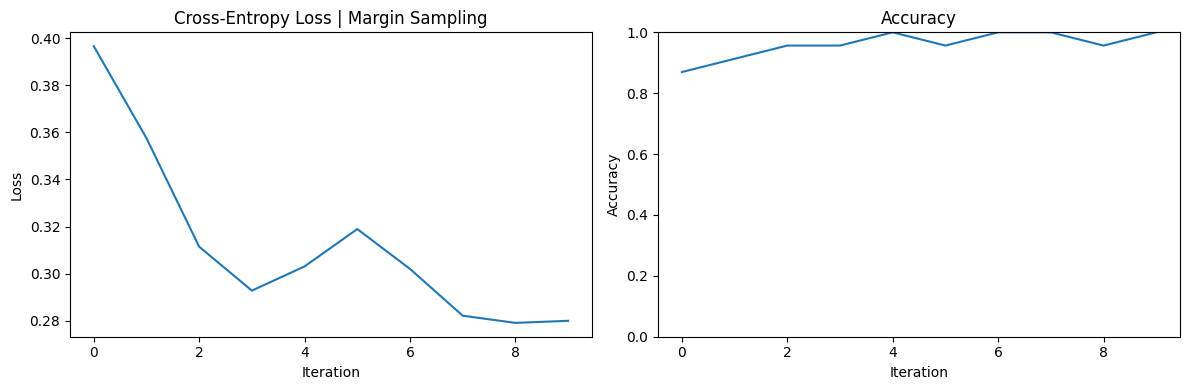

[(np.float64(0.3966597806584189), np.float64(0.8695652173913043)), (np.float64(0.3575770989816063), np.float64(0.9130434782608695)), (np.float64(0.31143303132497596), np.float64(0.9565217391304348)), (np.float64(0.2927705057610721), np.float64(0.9565217391304348)), (np.float64(0.30307055987337317), np.float64(1.0)), (np.float64(0.3189297212406639), np.float64(0.9565217391304348)), (np.float64(0.30198449111298914), np.float64(1.0)), (np.float64(0.28210707317607037), np.float64(1.0)), (np.float64(0.27905563482065354), np.float64(0.9565217391304348)), (np.float64(0.2799391913485527), np.float64(1.0))]


In [37]:
main(x_ground=X_iris, y_ground=y_true_iris)

In [38]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("data/data.csv")

# Discard the first column
df = df.iloc[:, 1:]

# Convert the diagnosis column to binary (0 for 'B' benign, 1 for 'M' malignant)
y = np.where(df.iloc[:, 0] == 'M', 1, 0)

# Drop last column and use the rest as features
X = df.iloc[:, 1:-1].values

print(X.shape, y.shape)

(569, 30) (569,)


c:\Users\kingk\PycharmProjects\ML_Active_Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\kingk\PycharmProjects\ML_Active_Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

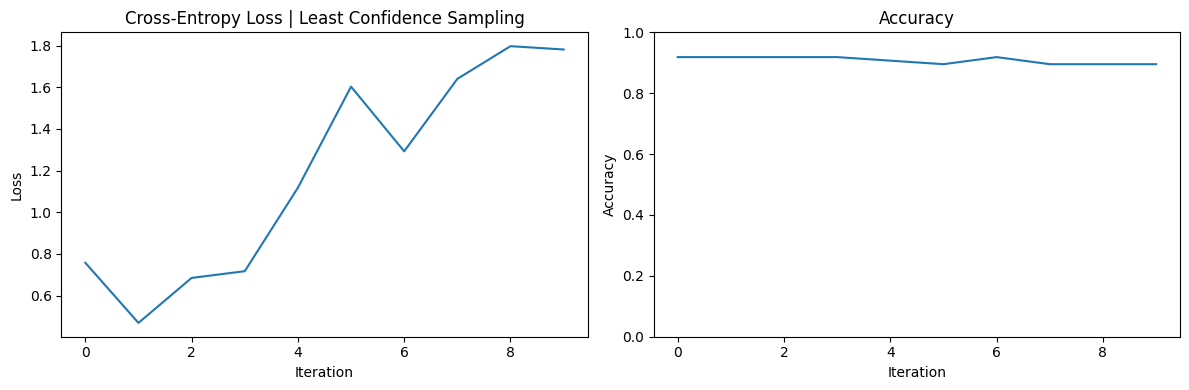

[(np.float64(0.7573987129782983), np.float64(0.9186046511627907)), (np.float64(0.46889275465855085), np.float64(0.9186046511627907)), (np.float64(0.6846722294398621), np.float64(0.9186046511627907)), (np.float64(0.7169437786961358), np.float64(0.9186046511627907)), (np.float64(1.1176513471900091), np.float64(0.9069767441860465)), (np.float64(1.602671565940769), np.float64(0.8953488372093024)), (np.float64(1.2922830345455096), np.float64(0.9186046511627907)), (np.float64(1.6400133127900056), np.float64(0.8953488372093024)), (np.float64(1.796910022005133), np.float64(0.8953488372093024)), (np.float64(1.780924678989891), np.float64(0.8953488372093024))]


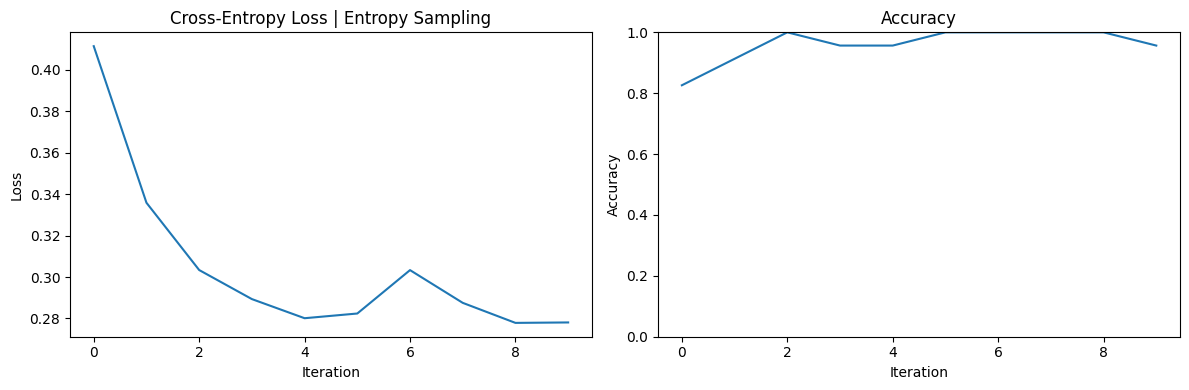

[(np.float64(0.41144968139309684), np.float64(0.8260869565217391)), (np.float64(0.3358582415032142), np.float64(0.9130434782608695)), (np.float64(0.3033736717838763), np.float64(1.0)), (np.float64(0.28934644092872547), np.float64(0.9565217391304348)), (np.float64(0.28011154704613483), np.float64(0.9565217391304348)), (np.float64(0.2823847767695105), np.float64(1.0)), (np.float64(0.3033351748593015), np.float64(1.0)), (np.float64(0.28753025644279484), np.float64(1.0)), (np.float64(0.277857769992152), np.float64(1.0)), (np.float64(0.27806889670261464), np.float64(0.9565217391304348))]


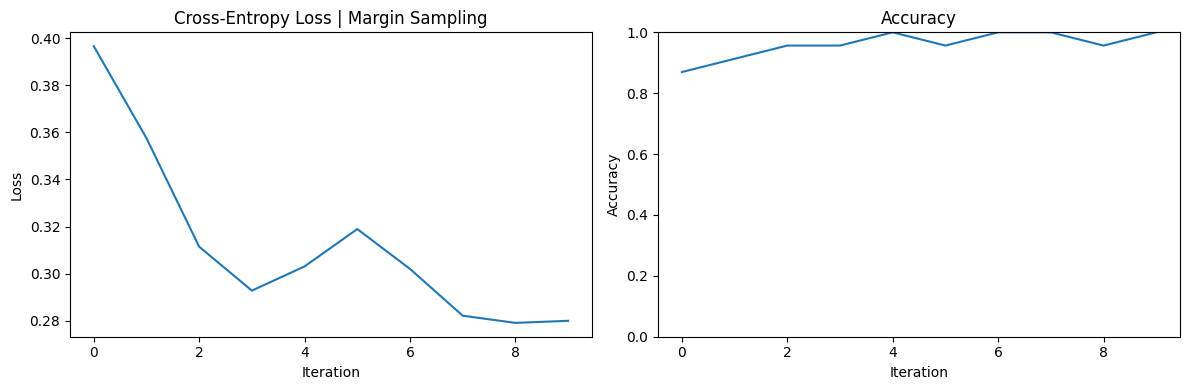

[(np.float64(0.3966597806584189), np.float64(0.8695652173913043)), (np.float64(0.3575770989816063), np.float64(0.9130434782608695)), (np.float64(0.31143303132497596), np.float64(0.9565217391304348)), (np.float64(0.2927705057610721), np.float64(0.9565217391304348)), (np.float64(0.30307055987337317), np.float64(1.0)), (np.float64(0.3189297212406639), np.float64(0.9565217391304348)), (np.float64(0.30198449111298914), np.float64(1.0)), (np.float64(0.28210707317607037), np.float64(1.0)), (np.float64(0.27905563482065354), np.float64(0.9565217391304348)), (np.float64(0.2799391913485527), np.float64(1.0))]


In [39]:
main(x_ground=X, y_ground=y)